In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
file_path = r"C:\Users\hp\Documents\Oasis Infobyte Tasks or Projects Documents\Task 6\Task 6 Documents\extracted csv\winequality-white.csv"

df = pd.read_csv(file_path, sep=";")

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (4898, 12)

Column Names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Data Types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Duplicate Rows:
937


In [5]:
print("\nDuplicate Rows Before Removal:")
print(df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("\nDataset Shape After Removing Duplicates:")
print(df.shape)

print("\nDuplicate Rows After Removal:")
print(df.duplicated().sum())


Duplicate Rows Before Removal:
937

Dataset Shape After Removing Duplicates:
(3961, 12)

Duplicate Rows After Removal:
0


In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000
mean,6.839346,0.280538,0.334332,5.914819,0.045905,34.889169,137.193512,0.993790,3.195458,0.490351,10.589358,5.854835
std,0.866860,0.103437,0.122446,4.861646,0.023103,17.210021,43.129065,0.002905,0.151546,0.113523,1.217076,0.890683
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.600000,0.035000,23.000000,106.000000,0.991620,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,4.700000,0.042000,33.000000,133.000000,0.993500,3.180000,0.480000,10.400000,6.000000
75%,7.300000,0.330000,0.390000,8.900000,0.050000,45.000000,166.000000,0.995710,3.290000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


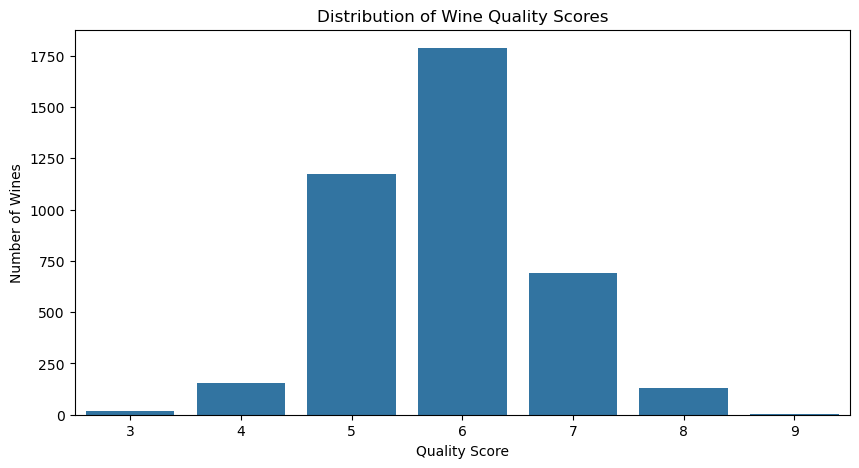

In [7]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="quality",
    order=sorted(df["quality"].unique())
)

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")
plt.show()

In [8]:
quality_counts = df["quality"].value_counts().sort_index()

print(quality_counts)

quality
3      20
4     153
5    1175
6    1788
7     689
8     131
9       5
Name: count, dtype: int64


In [9]:
quality_percentages = (
    df["quality"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print(quality_percentages)

quality
3     0.50
4     3.86
5    29.66
6    45.14
7    17.39
8     3.31
9     0.13
Name: proportion, dtype: float64


## Feature Engineering: Converting Wine Quality into Three Classes

The original `quality` variable contains seven possible scores ranging from 3 to 9. Some extreme quality scores have very few observations, making direct multi-class classification more difficult and increasing the effect of class imbalance.

To create a more practical classification problem, the quality scores are grouped into three ordered categories:

- **Low:** quality ≤ 5
- **Medium:** quality = 6
- **High:** quality ≥ 7

Quality score 6 is used as the Medium category because it represents the central and most common quality level in the dataset. Scores of 5 or below represent lower-quality wines, while scores of 7 or above represent higher-quality wines.

This three-class approach reduces the sparsity of the extreme original quality scores while preserving a meaningful distinction between low-, medium-, and high-quality wines.

In [10]:
def classify_quality(quality):
    if quality <= 5:
        return "Low"
    elif quality == 6:
        return "Medium"
    else:
        return "High"

df["quality_class"] = df["quality"].apply(classify_quality)

df[["quality", "quality_class"]].head(10)

,quality,quality_class
0,6,Medium
1,6,Medium
2,6,Medium
3,6,Medium
4,6,Medium
5,6,Medium
6,5,Low
7,5,Low
8,5,Low
9,7,High


In [11]:
class_counts = df["quality_class"].value_counts()

print(class_counts)

print("\nClass Percentages:")
print(
    df["quality_class"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

quality_class
Medium    1788
Low       1348
High       825
Name: count, dtype: int64

Class Percentages:
quality_class
Medium    45.14
Low       34.03
High      20.83
Name: proportion, dtype: float64


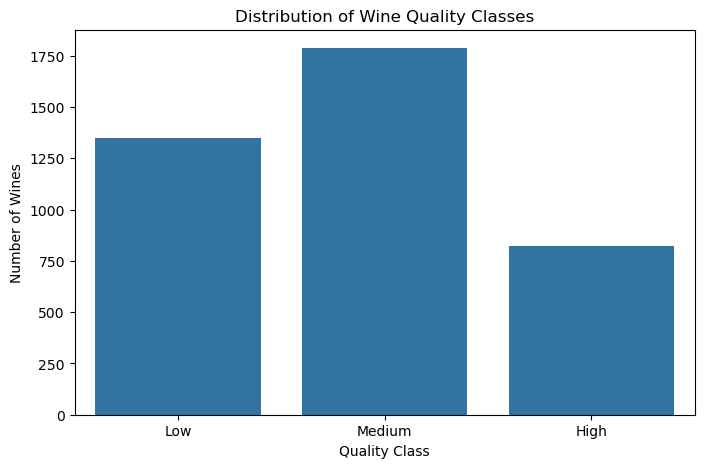

In [12]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="quality_class",
    order=["Low", "Medium", "High"]
)

plt.title("Distribution of Wine Quality Classes")
plt.xlabel("Quality Class")
plt.ylabel("Number of Wines")
plt.show()

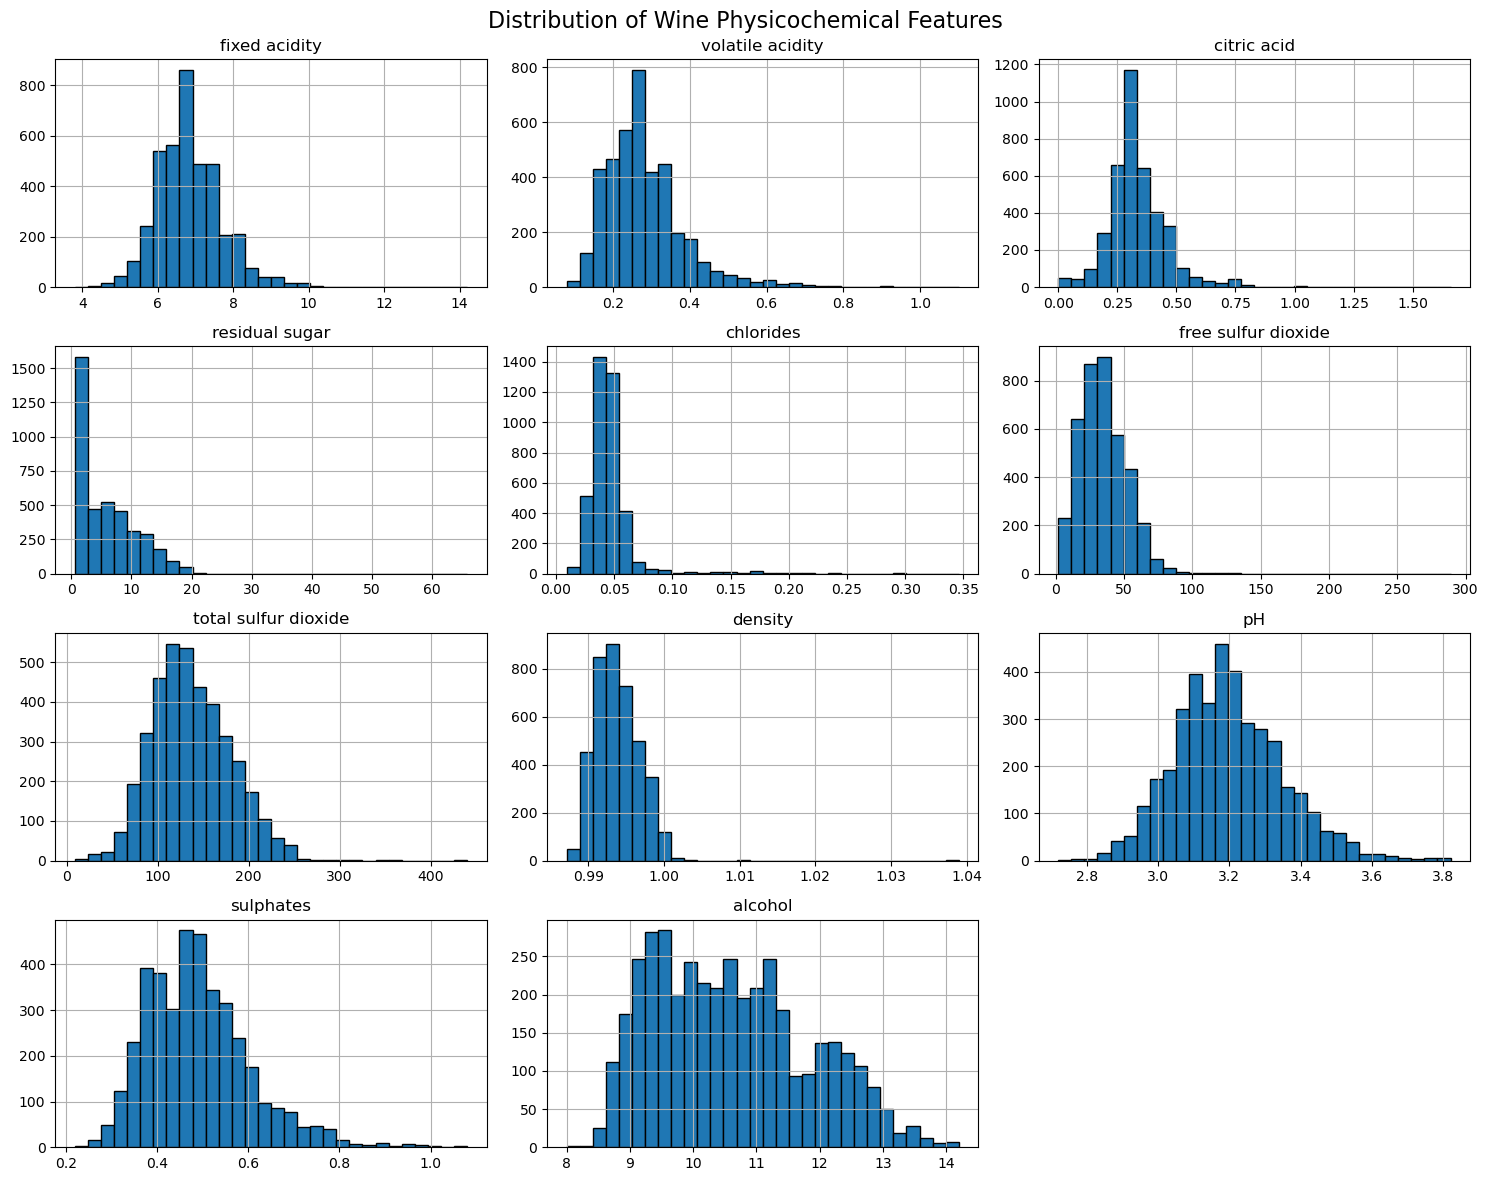

In [13]:
features = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

df[features].hist(
    figsize=(15, 12),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distribution of Wine Physicochemical Features", fontsize=16)
plt.tight_layout()
plt.show()

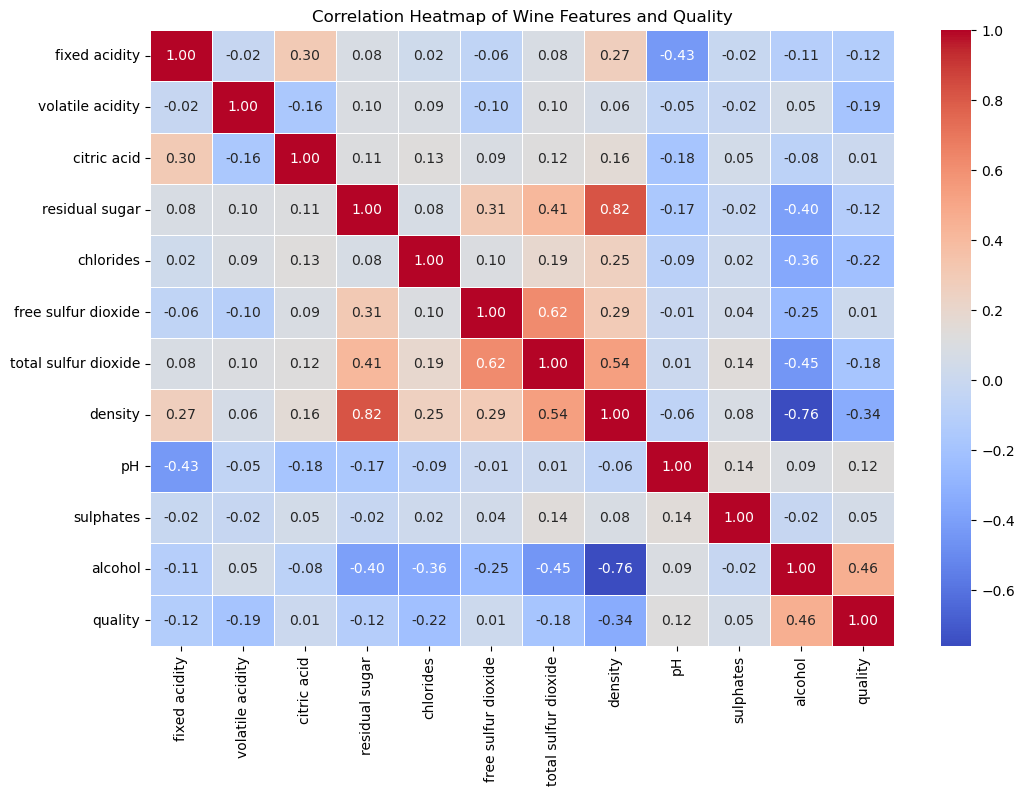

In [14]:
plt.figure(figsize=(12, 8))

correlation_matrix = df[features + ["quality"]].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Wine Features and Quality")
plt.show()

In [15]:
df["quality_class"]

0       Medium
1       Medium
2       Medium
3       Medium
4       Medium
         ...  
3956    Medium
3957       Low
3958    Medium
3959      High
3960    Medium
Name: quality_class, Length: 3961, dtype: object

In [16]:
class_distribution = pd.DataFrame({
    "Count": df["quality_class"].value_counts(),
    "Percentage": df["quality_class"].value_counts(normalize=True) * 100
})

class_distribution = class_distribution.loc[["Low", "Medium", "High"]]

class_distribution["Percentage"] = class_distribution["Percentage"].round(2)

class_distribution

,Count,Percentage
quality_class,,
Low,1348,34.03
Medium,1788,45.14
High,825,20.83


## Class Imbalance Discussion

The three wine-quality classes are not perfectly balanced. The Medium class represents the largest proportion of observations, followed by the Low class, while the High class contains the fewest observations.

Class imbalance can affect classification models because a model may become biased toward the majority class. In this case, a model could achieve relatively high overall accuracy by predicting Medium more frequently while performing less effectively on High-quality wines.

For this reason, accuracy alone is not sufficient for evaluating the models. Precision, recall, and F1-score are also considered, along with confusion matrices, to evaluate how well each model performs across all three classes.

To further reduce the effect of class imbalance during training, the Random Forest, SGD Classifier, and SVC models use `class_weight="balanced"`. This gives greater importance to observations from less represented classes during model training.

In [17]:
X = df[features]

y = df["quality_class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3961, 11)
y shape: (3961,)


In [18]:
print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)


Features:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Target:
quality_class


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [20]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: (3168, 11)
Testing set: (793, 11)

Training target distribution:
quality_class
Medium    0.451
Low       0.340
High      0.208
Name: proportion, dtype: float64

Testing target distribution:
quality_class
Medium    0.451
Low       0.340
High      0.208
Name: proportion, dtype: float64


In [21]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [22]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_accuracy, 4))

Random Forest Accuracy: 0.6003


In [23]:
print("Random Forest Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["High", "Low", "Medium"]
    )
)

Random Forest Classification Report:

              precision    recall  f1-score   support

        High       0.62      0.44      0.51       165
         Low       0.69      0.57      0.62       270
      Medium       0.55      0.70      0.62       358

    accuracy                           0.60       793
   macro avg       0.62      0.57      0.58       793
weighted avg       0.61      0.60      0.60       793



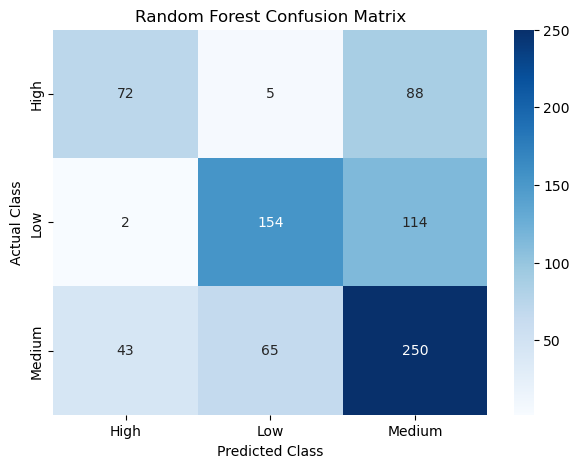

In [24]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=["High", "Low", "Medium"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["High", "Low", "Medium"],
    yticklabels=["High", "Low", "Medium"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [25]:
sgd_model = Pipeline([
    ("scaler", StandardScaler()),
    ("sgd", SGDClassifier(
        random_state=42,
        max_iter=2000,
        class_weight="balanced"
    ))
])

sgd_model.fit(X_train, y_train)

y_pred_sgd = sgd_model.predict(X_test)

In [26]:
sgd_accuracy = accuracy_score(y_test, y_pred_sgd)

print("SGD Classifier Accuracy:", round(sgd_accuracy, 4))

SGD Classifier Accuracy: 0.5069


In [27]:
print("SGD Classifier Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_sgd,
        target_names=["High", "Low", "Medium"]
    )
)

SGD Classifier Classification Report:

              precision    recall  f1-score   support

        High       0.47      0.57      0.51       165
         Low       0.51      0.76      0.61       270
      Medium       0.53      0.29      0.37       358

    accuracy                           0.51       793
   macro avg       0.51      0.54      0.50       793
weighted avg       0.51      0.51      0.48       793



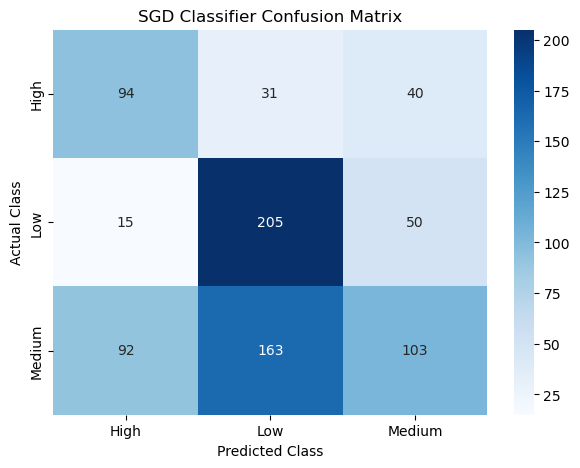

In [28]:
cm_sgd = confusion_matrix(
    y_test,
    y_pred_sgd,
    labels=["High", "Low", "Medium"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_sgd,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["High", "Low", "Medium"],
    yticklabels=["High", "Low", "Medium"]
)

plt.title("SGD Classifier Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [29]:
svc_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(
        class_weight="balanced",
        random_state=42
    ))
])

svc_model.fit(X_train, y_train)

y_pred_svc = svc_model.predict(X_test)

In [30]:
svc_accuracy = accuracy_score(y_test, y_pred_svc)

print("SVC Accuracy:", round(svc_accuracy, 4))

SVC Accuracy: 0.5637


In [31]:
print("SVC Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_svc,
        target_names=["High", "Low", "Medium"]
    )
)

SVC Classification Report:

              precision    recall  f1-score   support

        High       0.44      0.67      0.53       165
         Low       0.66      0.71      0.68       270
      Medium       0.58      0.40      0.48       358

    accuracy                           0.56       793
   macro avg       0.56      0.60      0.56       793
weighted avg       0.58      0.56      0.56       793



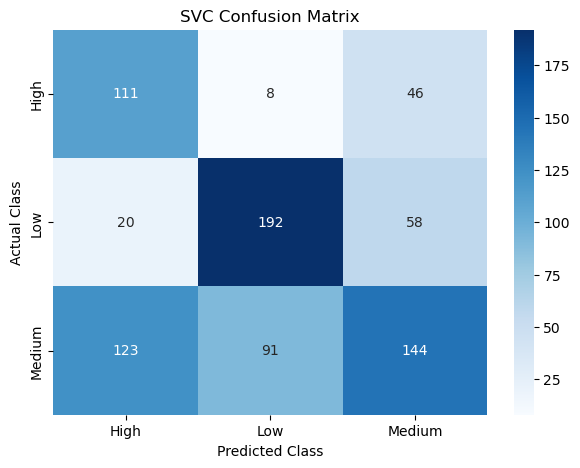

In [32]:
cm_svc = confusion_matrix(
    y_test,
    y_pred_svc,
    labels=["High", "Low", "Medium"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_svc,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["High", "Low", "Medium"],
    yticklabels=["High", "Low", "Medium"]
)

plt.title("SVC Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [33]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
10,alcohol,0.150069
7,density,0.113995
1,volatile acidity,0.093893
5,free sulfur dioxide,0.093143
6,total sulfur dioxide,0.087780
4,chlorides,0.086834
3,residual sugar,0.080799
8,pH,0.079109
2,citric acid,0.074843
9,sulphates,0.071764


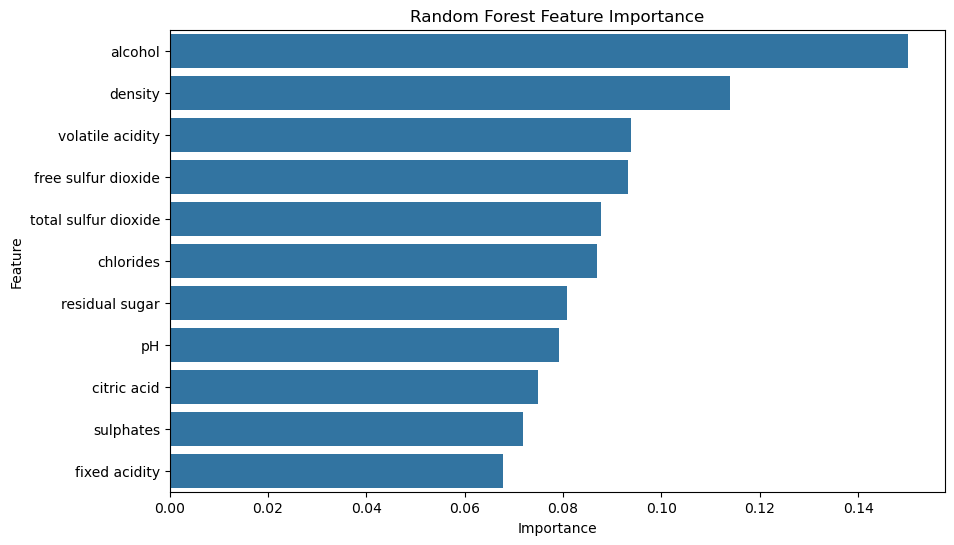

In [34]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [35]:
# Generate weighted-average metrics for each model

rf_report = classification_report(
    y_test,
    y_pred_rf,
    output_dict=True
)

sgd_report = classification_report(
    y_test,
    y_pred_sgd,
    output_dict=True
)

svc_report = classification_report(
    y_test,
    y_pred_svc,
    output_dict=True
)

# Create comparison table
model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SGD Classifier",
        "SVC"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_sgd),
        accuracy_score(y_test, y_pred_svc)
    ],
    "Weighted Precision": [
        rf_report["weighted avg"]["precision"],
        sgd_report["weighted avg"]["precision"],
        svc_report["weighted avg"]["precision"]
    ],
    "Weighted Recall": [
        rf_report["weighted avg"]["recall"],
        sgd_report["weighted avg"]["recall"],
        svc_report["weighted avg"]["recall"]
    ],
    "Weighted F1-Score": [
        rf_report["weighted avg"]["f1-score"],
        sgd_report["weighted avg"]["f1-score"],
        svc_report["weighted avg"]["f1-score"]
    ]
})

model_comparison = model_comparison.sort_values(
    by="Weighted F1-Score",
    ascending=False
).reset_index(drop=True)

model_comparison.round(4)

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1-Score
0,Random Forest,0.6003,0.6118,0.6003,0.5972
1,SVC,0.5637,0.5777,0.5637,0.5578
2,SGD Classifier,0.5069,0.5132,0.5069,0.4843


In [36]:
best_model = model_comparison.iloc[0]

print(
    f"The best-performing model is {best_model['Model']} "
    f"with an accuracy of {best_model['Accuracy']:.2%} "
    f"and a weighted F1-score of {best_model['Weighted F1-Score']:.2f}."
)

The best-performing model is Random Forest with an accuracy of 60.03% and a weighted F1-score of 0.60.


## Final Conclusion

Three classification models were evaluated for wine quality prediction: Random Forest, SVC, and SGD Classifier.

Random Forest achieved the best overall performance with an accuracy of 60.03%, weighted precision of 61.18%, weighted recall of 60.03%, and weighted F1-score of 59.72%. SVC achieved an accuracy of 56.37% and a weighted F1-score of 55.78%, while SGD Classifier achieved an accuracy of 50.69% and a weighted F1-score of 48.43%.

Therefore, Random Forest is the most suitable model for deployment among the three models tested because it achieved the highest accuracy, weighted precision, weighted recall, and weighted F1-score.

The model results also demonstrate why evaluating multiple metrics is important when working with imbalanced classes. Accuracy alone does not provide a complete picture of classification performance, so weighted precision, recall, F1-score, and confusion matrices were also considered.

Further hyperparameter tuning, cross-validation, and additional class-imbalance techniques could be explored to improve model performance before actual production deployment.